# Polynomial Regression

What if your data doesn't look linear at all? Let's look at some more realistic-looking page speed / purchase data:

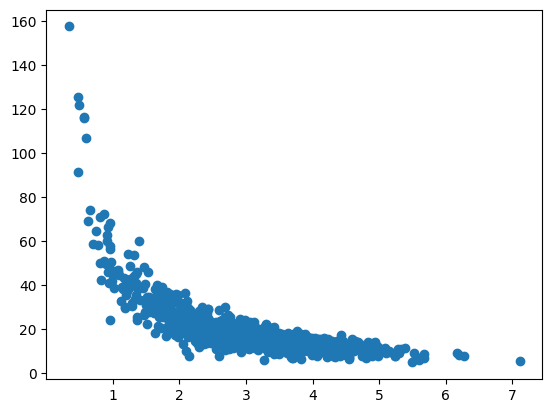

In [1]:
%matplotlib inline
from pylab import *
import numpy as np

np.random.seed(2)
pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds

scatter(pageSpeeds, purchaseAmount)

numpy has a handy polyfit function we can use, to let us construct an nth-degree polynomial model of our data that minimizes squared error. Let's try it with a 4th degree polynomial:

In [15]:
x = np.array(pageSpeeds)
y = np.array(purchaseAmount)

p2 = np.poly1d(np.polyfit(x, y, 2))
p4 = np.poly1d(np.polyfit(x, y, 4))
p8 = np.poly1d(np.polyfit(x, y, 8))

# an example of predicting purchaseAmount, given a pagespeed
print(p2(4))
print(p4(4))
print(p8(4))

10.109861591614134
13.732577317327497
12.628112274603382


We'll visualize our original scatter plot, together with a plot of our predicted values using the polynomial for page speed times ranging from 0-7 seconds:

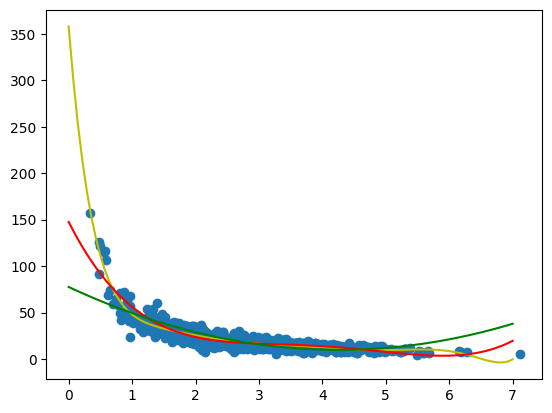

In [12]:
import matplotlib.pyplot as plt

xp = np.linspace(0, 7, 100)
plt.scatter(x, y)
plt.plot(xp, p8(xp), c='y')
plt.plot(xp, p4(xp), c='r')
plt.plot(xp, p2(xp), c='g')
plt.show()

Looks pretty good! Let's measure the r-squared error:

In [13]:
!pip install scipy
!pip install Scikit-learn

from sklearn.metrics import r2_score

r2_2 = r2_score(y, p2(x))
r2_4 = r2_score(y, p4(x))
r2_8 = r2_score(y, p8(x))

print(r2_2)
print(r2_4)
print(r2_8)



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


0.6927446350535892
0.8293766396303073
0.8814395663681477



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Activity

Try different polynomial orders. Can you get a better fit with higher orders? Do you start to see overfitting, even though the r-squared score looks good for this particular data set?